# Avance 2. Ingenieria de caracteristicas

**Proyecto:** AURORA  
**Nombre completo:** Analisis Unificado de Riesgo Operativo y Readiness con Aprendizaje Automatico  
**Entregable:** `Avance2.4`  
**Equipo:** 4  
**Modalidad:** individual  
**Dataset:** sintetico y sanitizado

## Declaracion de privacidad y confidencialidad

Esta libreta usa exclusivamente datos ficticios generados de forma sintetica para fines academicos. Ninguna fila, identificador, metrica, distribucion o categoria corresponde a datos reales de Oracle. Por confidencialidad, no se incluyen nombres de repositorios, sistemas internos, clientes, arquitectura, tecnologias propietarias, credenciales, procedimientos operativos ni informacion sensible.

El objetivo es demostrar tecnicas de ingenieria de caracteristicas aplicables a un caso empresarial real sin exponer informacion confidencial.

## 1. Objetivo de la fase

En el Avance 1 se realizo el analisis exploratorio de datos. En esta fase se preparan las variables para aprendizaje automatico con el objetivo de predecir `high_risk_change`, una variable sintetica que indica si un cambio podria requerir mayor validacion.

La libreta cubre los criterios de la rubrica:

- construccion de nuevas caracteristicas significativas;
- codificacion de variables categoricas;
- escalamiento y transformaciones para mejorar convergencia y reducir sesgo;
- seleccion y extraccion de caracteristicas;
- conclusiones de preparacion de datos en el contexto CRISP-ML.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, f_classif, chi2
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_SEED = 42
INPUT_PATH = Path("../avance_1_eda/data/release_readiness_synthetic.csv")
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_READY_PATH = OUTPUT_DIR / "aurora_features_model_ready.csv"
SUMMARY_PATH = OUTPUT_DIR / "aurora_feature_engineering_summary.csv"
print(f"Dataset de entrada: {INPUT_PATH}")

Dataset de entrada: ../avance_1_eda/data/release_readiness_synthetic.csv


## 2. Carga y revision inicial

Se parte del dataset sintetico del Avance 1 para mantener continuidad metodologica. Antes de transformar los datos se separan la variable objetivo y las columnas que no deben entrar como predictores.

In [2]:
df = pd.read_csv(INPUT_PATH)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

target_col = "high_risk_change"
leakage_cols = ["change_id", "failure_category", "recommended_validation_scope", "readiness_score"]

print("Variable objetivo:", target_col)
print("Columnas excluidas para evitar fuga de informacion:", leakage_cols)
print("Distribucion de la variable objetivo:")
display((df[target_col].value_counts(normalize=True) * 100).round(2).to_frame("porcentaje"))

Filas: 2,400
Columnas: 28


,change_id,week,change_type,component_area,synthetic_component_id,branch_type,validation_level,environment_profile,files_changed,lines_added,lines_deleted,modules_touched,author_experience_months,prior_failures_90d,historical_failure_rate,pipeline_duration_min,coverage_delta_pct,tests_impacted_count,critical_files_touched,documentation_refs_count,open_defects_linked,release_pressure_score,reviewer_count,validation_gap_count,readiness_score,recommended_validation_scope,failure_category,high_risk_change
0,CHG-00001,2,configuration,functional_area_b,CMP-043,development,integrated_checks,profile_standard,6,140,41,1,40.1000,1,0.2300,23.1000,-0.7600,3,0,2.0000,0,60.2000,2,0,80.8000,focused_validation,none,0
1,CHG-00002,16,configuration,functional_area_a,CMP-001,development,basic_checks,profile_standard,8,327,78,2,15.0000,3,0.1840,41.4000,0.0900,36,0,3.0000,1,30.4000,7,2,71.9000,expanded_validation,none,0
2,CHG-00003,14,test,functional_area_d,CMP-008,development,integrated_checks,profile_extended,11,4532,1296,2,50.1000,0,0.1770,21.8000,-3.7800,20,0,0.0000,0,50.4000,2,1,64.0000,expanded_validation,none,0
3,CHG-00004,9,refactor,functional_area_b,CMP-002,development,broad_regression_checks,profile_standard,13,193,55,3,31.2000,1,0.1900,37.8000,-1.3500,15,0,1.0000,1,3.9000,1,3,59.0000,broad_validation,none,0
4,CHG-00005,9,feature,functional_area_g,CMP-004,development,readiness_review,profile_extended,6,107,136,1,24.7000,0,0.3100,22.7000,0.7800,25,0,2.0000,0,57.0000,1,0,81.0000,focused_validation,none,0


Variable objetivo: high_risk_change
Columnas excluidas para evitar fuga de informacion: ['change_id', 'failure_category', 'recommended_validation_scope', 'readiness_score']
Distribucion de la variable objetivo:


,porcentaje
high_risk_change,
0,72.0000
1,28.0000


### Justificacion de exclusiones

- `change_id` es un identificador y no aporta patron generalizable.
- `failure_category` representa una clasificacion posterior al evento; incluirla permitiria al modelo conocer informacion que no estaria disponible antes de decidir validaciones.
- `recommended_validation_scope` y `readiness_score` son variables derivadas de decision, por lo que tambien podrian filtrar informacion del objetivo.

El conjunto predictivo conserva senales previas o contemporaneas al cambio, como tamano, contexto, cobertura sintetica, evidencia disponible e historial sintetico.

In [3]:
base_predictors = [col for col in df.columns if col not in leakage_cols + [target_col]]
X_raw = df[base_predictors].copy()
y = df[target_col].copy()

feature_overview = pd.DataFrame({
    "variable": X_raw.columns,
    "dtype": X_raw.dtypes.astype(str).values,
    "faltantes": X_raw.isna().sum().values,
    "cardinalidad": [X_raw[col].nunique(dropna=False) for col in X_raw.columns]
})
display(feature_overview)

,variable,dtype,faltantes,cardinalidad
0,week,int64,0,20
1,change_type,object,0,6
2,component_area,object,0,8
3,synthetic_component_id,object,0,119
4,branch_type,object,0,3
5,validation_level,object,0,5
6,environment_profile,object,0,4
7,files_changed,int64,0,94
8,lines_added,int64,0,484
9,lines_deleted,int64,0,386


## 3. Construccion de nuevas caracteristicas

Las nuevas variables reflejan conocimiento de dominio de manera generica: tamano relativo del cambio, densidad de modificacion, intensidad de pruebas, brechas de evidencia, presion de liberacion y completitud de informacion. Estas variables buscan capturar relaciones no lineales simples y hacer mas explicito el contexto de riesgo.

In [4]:
X = X_raw.copy()

# Indicadores de ausencia antes de imputar. La ausencia de evidencia puede ser informativa.
for col in ["coverage_delta_pct", "documentation_refs_count", "author_experience_months"]:
    X[f"{col}_was_missing"] = X[col].isna().astype(int)

# Variables de tamano y densidad del cambio.
X["total_lines_changed"] = X["lines_added"] + X["lines_deleted"]
X["net_lines_changed"] = X["lines_added"] - X["lines_deleted"]
X["change_density_lines_per_file"] = X["total_lines_changed"] / np.maximum(X["files_changed"], 1)
X["tests_per_file_changed"] = X["tests_impacted_count"] / np.maximum(X["files_changed"], 1)
X["tests_per_module_touched"] = X["tests_impacted_count"] / np.maximum(X["modules_touched"], 1)
X["defects_per_module"] = X["open_defects_linked"] / np.maximum(X["modules_touched"], 1)

# Variables de evidencia y contexto operativo.
X["validation_gap_ratio"] = X["validation_gap_count"] / np.maximum(X["tests_impacted_count"], 1)
missing_evidence_count = (
    X["coverage_delta_pct_was_missing"]
    + X["documentation_refs_count_was_missing"]
    + X["author_experience_months_was_missing"]
)
X["evidence_completeness_score"] = 1 - (missing_evidence_count / 3)
X["is_large_change"] = (X["total_lines_changed"] >= X["total_lines_changed"].quantile(0.75)).astype(int)
X["is_high_pressure"] = (X["release_pressure_score"] >= X["release_pressure_score"].quantile(0.75)).astype(int)
X["is_negative_coverage_delta"] = (X["coverage_delta_pct"] < 0).fillna(False).astype(int)

new_features = [
    "coverage_delta_pct_was_missing", "documentation_refs_count_was_missing", "author_experience_months_was_missing",
    "total_lines_changed", "net_lines_changed", "change_density_lines_per_file",
    "tests_per_file_changed", "tests_per_module_touched", "defects_per_module",
    "validation_gap_ratio", "evidence_completeness_score", "is_large_change",
    "is_high_pressure", "is_negative_coverage_delta"
]

display(X[new_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
coverage_delta_pct_was_missing,"2,400.0000",0.1150,0.3191,0.0000,0.0000,0.0000,0.0000,1.0000
documentation_refs_count_was_missing,"2,400.0000",0.0700,0.2552,0.0000,0.0000,0.0000,0.0000,1.0000
author_experience_months_was_missing,"2,400.0000",0.0450,0.2073,0.0000,0.0000,0.0000,0.0000,1.0000
total_lines_changed,"2,400.0000",419.7979,765.0882,66.0000,199.7500,256.0000,333.2500,"7,106.0000"
net_lines_changed,"2,400.0000",102.2546,284.5983,"-1,131.0000",3.0000,58.0000,118.0000,"3,542.0000"
change_density_lines_per_file,"2,400.0000",42.9882,93.2841,4.8375,21.4444,27.8944,36.7778,"1,636.0000"
tests_per_file_changed,"2,400.0000",7.2148,17.4309,0.1000,3.1818,4.3333,5.6667,245.5000
tests_per_module_touched,"2,400.0000",40.1984,93.4050,0.5000,16.5000,23.8392,33.0000,992.0000
defects_per_module,"2,400.0000",0.4074,0.6181,0.0000,0.0000,0.0000,0.6667,6.0000
validation_gap_ratio,"2,400.0000",0.0644,0.2323,0.0000,0.0000,0.0270,0.0571,4.0000


## 4. Tratamiento de faltantes y alta cardinalidad

Se imputan valores faltantes despues de crear indicadores de ausencia. Para variables numericas se usa mediana porque varias distribuciones son sesgadas y contienen valores extremos. Para categoricas se usa `unknown` para conservar la senal de ausencia.

La variable `synthetic_component_id` tiene alta cardinalidad; se agrupan componentes poco frecuentes en `other_component` para reducir dimensionalidad y mejorar generalizacion.

In [5]:
X_processed = X.copy()

# Agrupacion de alta cardinalidad.
component_counts = X_processed["synthetic_component_id"].value_counts(dropna=False)
common_components = component_counts[component_counts >= 25].index
X_processed["synthetic_component_grouped"] = np.where(
    X_processed["synthetic_component_id"].isin(common_components),
    X_processed["synthetic_component_id"],
    "other_component"
)
X_processed = X_processed.drop(columns=["synthetic_component_id"])

# Imputacion explicita para tablas intermedias y salidas de auditoria.
numeric_cols_before = X_processed.select_dtypes(include="number").columns.tolist()
categorical_cols_before = X_processed.select_dtypes(exclude="number").columns.tolist()

for col in numeric_cols_before:
    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
for col in categorical_cols_before:
    X_processed[col] = X_processed[col].fillna("unknown")

print("Faltantes despues de imputacion:", int(X_processed.isna().sum().sum()))
print("Cardinalidad original synthetic_component_id:", X_raw["synthetic_component_id"].nunique(dropna=False))
print("Cardinalidad agrupada synthetic_component_grouped:", X_processed["synthetic_component_grouped"].nunique(dropna=False))
display(X_processed.head())

Faltantes despues de imputacion: 0
Cardinalidad original synthetic_component_id: 119
Cardinalidad agrupada synthetic_component_grouped: 18


,week,change_type,component_area,branch_type,validation_level,environment_profile,files_changed,lines_added,lines_deleted,modules_touched,author_experience_months,prior_failures_90d,historical_failure_rate,pipeline_duration_min,coverage_delta_pct,tests_impacted_count,critical_files_touched,documentation_refs_count,open_defects_linked,release_pressure_score,reviewer_count,validation_gap_count,coverage_delta_pct_was_missing,documentation_refs_count_was_missing,author_experience_months_was_missing,total_lines_changed,net_lines_changed,change_density_lines_per_file,tests_per_file_changed,tests_per_module_touched,defects_per_module,validation_gap_ratio,evidence_completeness_score,is_large_change,is_high_pressure,is_negative_coverage_delta,synthetic_component_grouped
0,2,configuration,functional_area_b,development,integrated_checks,profile_standard,6,140,41,1,40.1000,1,0.2300,23.1000,-0.7600,3,0,2.0000,0,60.2000,2,0,0,0,0,181,99,30.1667,0.5000,3.0000,0.0000,0.0000,1.0000,0,0,1,other_component
1,16,configuration,functional_area_a,development,basic_checks,profile_standard,8,327,78,2,15.0000,3,0.1840,41.4000,0.0900,36,0,3.0000,1,30.4000,7,2,0,0,0,405,249,50.6250,4.5000,18.0000,0.5000,0.0556,1.0000,1,0,0,CMP-001
2,14,test,functional_area_d,development,integrated_checks,profile_extended,11,4532,1296,2,50.1000,0,0.1770,21.8000,-3.7800,20,0,0.0000,0,50.4000,2,1,0,0,0,5828,3236,529.8182,1.8182,10.0000,0.0000,0.0500,1.0000,1,0,1,CMP-008
3,9,refactor,functional_area_b,development,broad_regression_checks,profile_standard,13,193,55,3,31.2000,1,0.1900,37.8000,-1.3500,15,0,1.0000,1,3.9000,1,3,0,0,0,248,138,19.0769,1.1538,5.0000,0.3333,0.2000,1.0000,0,0,1,CMP-002
4,9,feature,functional_area_g,development,readiness_review,profile_extended,6,107,136,1,24.7000,0,0.3100,22.7000,0.7800,25,0,2.0000,0,57.0000,1,0,0,0,0,243,-29,40.5000,4.1667,25.0000,0.0000,0.0000,1.0000,0,0,0,CMP-004


## 5. Transformaciones y escalamiento

Las variables de conteo y duracion suelen tener sesgo a la derecha. Se aplica `log1p` para comprimir colas largas sin perder registros con valor cero. Posteriormente, las variables numericas se estandarizan con `StandardScaler` para que algoritmos sensibles a escala converjan mejor y no favorezcan variables con magnitudes grandes.

In [6]:
log_transform_cols = [
    "files_changed", "lines_added", "lines_deleted", "modules_touched",
    "pipeline_duration_min", "tests_impacted_count", "open_defects_linked",
    "total_lines_changed", "change_density_lines_per_file",
    "tests_per_file_changed", "tests_per_module_touched"
]

X_transformed = X_processed.copy()
for col in log_transform_cols:
    if col in X_transformed.columns:
        X_transformed[f"log1p_{col}"] = np.log1p(X_transformed[col].clip(lower=0))

# Para evitar duplicidad fuerte, se eliminan las columnas originales de conteo transformadas,
# conservando sus versiones logaritmicas.
X_transformed = X_transformed.drop(columns=[col for col in log_transform_cols if col in X_transformed.columns])

numeric_cols = X_transformed.select_dtypes(include="number").columns.tolist()
categorical_cols = X_transformed.select_dtypes(exclude="number").columns.tolist()

print(f"Variables numericas para escalamiento: {len(numeric_cols)}")
print(f"Variables categoricas para one-hot encoding: {len(categorical_cols)}")
print("Categoricas:", categorical_cols)

Variables numericas para escalamiento: 31
Variables categoricas para one-hot encoding: 6
Categoricas: ['change_type', 'component_area', 'branch_type', 'validation_level', 'environment_profile', 'synthetic_component_grouped']


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_matrix = preprocessor.fit_transform(X_transformed)
feature_names = preprocessor.get_feature_names_out()
X_model = pd.DataFrame(X_matrix, columns=feature_names, index=X_transformed.index)

# Limpiar nombres para evitar caracteres incomodos en CSV y modelos posteriores.
X_model.columns = (
    X_model.columns
    .str.replace("[^0-9a-zA-Z_]+", "_", regex=True)
    .str.strip("_")
)

model_ready = X_model.copy()
model_ready[target_col] = y.values

print("Shape model-ready:", model_ready.shape)
print("Faltantes en model-ready:", int(model_ready.isna().sum().sum()))
display(model_ready.head())

Shape model-ready: (2400, 76)
Faltantes en model-ready: 0


,week,author_experience_months,prior_failures_90d,historical_failure_rate,coverage_delta_pct,critical_files_touched,documentation_refs_count,release_pressure_score,reviewer_count,validation_gap_count,coverage_delta_pct_was_missing,documentation_refs_count_was_missing,author_experience_months_was_missing,net_lines_changed,defects_per_module,validation_gap_ratio,evidence_completeness_score,is_large_change,is_high_pressure,is_negative_coverage_delta,log1p_files_changed,log1p_lines_added,log1p_lines_deleted,log1p_modules_touched,log1p_pipeline_duration_min,log1p_tests_impacted_count,log1p_open_defects_linked,log1p_total_lines_changed,log1p_change_density_lines_per_file,log1p_tests_per_file_changed,log1p_tests_per_module_touched,change_type_bugfix,change_type_configuration,change_type_dependency,change_type_feature,change_type_refactor,change_type_test,component_area_functional_area_a,component_area_functional_area_b,component_area_functional_area_c,component_area_functional_area_d,component_area_functional_area_e,component_area_functional_area_f,component_area_functional_area_g,component_area_functional_area_h,branch_type_development,branch_type_hotfix,branch_type_release_candidate,validation_level_basic_checks,validation_level_broad_regression_checks,validation_level_component_checks,validation_level_integrated_checks,validation_level_readiness_review,environment_profile_profile_dependency,environment_profile_profile_distributed,environment_profile_profile_extended,environment_profile_profile_standard,synthetic_component_grouped_CMP_001,synthetic_component_grouped_CMP_002,synthetic_component_grouped_CMP_003,synthetic_component_grouped_CMP_004,synthetic_component_grouped_CMP_005,synthetic_component_grouped_CMP_006,synthetic_component_grouped_CMP_007,synthetic_component_grouped_CMP_008,synthetic_component_grouped_CMP_009,synthetic_component_grouped_CMP_010,synthetic_component_grouped_CMP_011,synthetic_component_grouped_CMP_012,synthetic_component_grouped_CMP_013,synthetic_component_grouped_CMP_014,synthetic_component_grouped_CMP_015,synthetic_component_grouped_CMP_016,synthetic_component_grouped_CMP_018,synthetic_component_grouped_other_component,high_risk_change
0,-1.4728,0.2347,0.0915,0.1856,-0.1772,-0.4519,0.1895,0.2323,-0.2958,-1.1709,-0.3605,-0.2744,-0.2171,-0.0114,-0.6592,-0.2774,0.4984,-0.5774,-0.5818,1.0228,-0.7516,-0.2316,-1.1769,-0.8270,-0.8988,-2.4611,-0.8322,-0.6650,0.0211,-2.0416,-2.3226,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0
1,0.9512,-1.0460,2.2036,-0.2208,0.1928,-0.4519,0.9709,-1.4958,3.4020,0.5595,-0.3605,-0.2744,-0.2171,0.5157,0.1498,-0.0382,0.4984,1.7321,-0.5818,-0.9777,-0.3000,0.9155,-0.3454,0.1395,0.0663,-0.1418,0.6941,0.5436,0.8712,-0.0062,-0.3426,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
2,0.6049,0.7450,-0.9645,-0.2827,-1.4917,-0.4519,-1.3733,-0.3360,-0.2958,-0.3057,-0.3605,-0.2744,-0.2171,11.0134,-0.6592,-0.0621,0.4984,1.7321,-0.5818,1.0228,0.2169,4.4835,3.3378,0.1395,-0.9936,-0.7323,-0.8322,4.5570,4.7968,-1.0537,-1.0371,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
3,-0.2608,-0.2194,0.0915,-0.1678,-0.4340,-0.4519,-0.5919,-3.0325,-1.0354,1.4246,-0.3605,-0.2744,-0.2171,0.1256,-0.1199,0.5838,0.4984,-0.5774,-0.5818,1.0228,0.

In [8]:
scaled_check = X_model[numeric_cols].agg(["mean", "std"]).T
scaled_check["abs_mean"] = scaled_check["mean"].abs()
scaled_check["std_distance_from_1"] = (scaled_check["std"] - 1).abs()
scaled_check.sort_values("abs_mean", ascending=False).head(10)

,mean,std,abs_mean,std_distance_from_1
log1p_change_density_lines_per_file,0.0000,1.0002,0.0000,0.0002
log1p_files_changed,-0.0000,1.0002,0.0000,0.0002
log1p_total_lines_changed,0.0000,1.0002,0.0000,0.0002
log1p_pipeline_duration_min,-0.0000,1.0002,0.0000,0.0002
log1p_modules_touched,0.0000,1.0002,0.0000,0.0002
log1p_lines_deleted,-0.0000,1.0002,0.0000,0.0002
log1p_tests_impacted_count,0.0000,1.0002,0.0000,0.0002
log1p_tests_per_module_touched,0.0000,1.0002,0.0000,0.0002
release_pressure_score,-0.0000,1.0002,0.0000,0.0002
author_experience_months,-0.0000,1.0002,0.0000,0.0002


## 6. Seleccion por umbral de varianza

El umbral de varianza ayuda a eliminar variables constantes o casi constantes. Esto reduce complejidad y evita columnas que no aportan informacion al modelo.

In [9]:
variance_selector = VarianceThreshold(threshold=0.001)
variance_selector.fit(X_model)
variance_support = pd.Series(variance_selector.get_support(), index=X_model.columns, name="kept_by_variance")
low_variance_features = variance_support[~variance_support].index.tolist()

print("Variables eliminadas por baja varianza:", len(low_variance_features))
print(low_variance_features[:20])

X_var_selected = X_model.loc[:, variance_support.values]
print("Shape despues de umbral de varianza:", X_var_selected.shape)

Variables eliminadas por baja varianza: 0
[]
Shape despues de umbral de varianza: (2400, 75)


## 7. Seleccion por correlacion

Se revisan correlaciones absolutas altas para identificar redundancia. Cuando dos variables explican practicamente la misma informacion, conservar ambas puede aumentar complejidad sin aportar interpretabilidad.

In [10]:
corr_matrix = X_var_selected.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "abs_correlation"})
    .query("abs_correlation >= 0.90")
    .sort_values("abs_correlation", ascending=False)
)

features_to_drop_corr = set()
for _, row in high_corr_pairs.iterrows():
    if row["feature_b"] not in features_to_drop_corr and row["feature_a"] not in features_to_drop_corr:
        features_to_drop_corr.add(row["feature_b"])

X_corr_selected = X_var_selected.drop(columns=sorted(features_to_drop_corr))
print("Pares con correlacion >= 0.90:", len(high_corr_pairs))
print("Variables eliminadas por redundancia:", len(features_to_drop_corr))
display(high_corr_pairs.head(20))
print("Shape despues de filtro de correlacion:", X_corr_selected.shape)

Pares con correlacion >= 0.90: 2
Variables eliminadas por redundancia: 2


,feature_a,feature_b,abs_correlation
1349,log1p_lines_added,log1p_total_lines_changed,0.9306
1740,log1p_tests_per_file_changed,log1p_tests_per_module_touched,0.9004


Shape despues de filtro de correlacion: (2400, 73)


## 8. Metodos de filtrado supervisado

Se aplican ANOVA F-score para variables numericas escaladas y chi-cuadrado para variables categoricas codificadas en one-hot. Estos metodos permiten priorizar variables que muestran mayor asociacion individual con la variable objetivo.

In [11]:
# ANOVA sobre variables numericas transformadas/escaladas disponibles.
numeric_available = [col for col in numeric_cols if col in X_corr_selected.columns]
f_values, f_pvalues = f_classif(X_corr_selected[numeric_available], y)
anova_ranking = pd.DataFrame({
    "feature": numeric_available,
    "anova_f_score": f_values,
    "p_value": f_pvalues
}).sort_values("anova_f_score", ascending=False)

display(anova_ranking.head(20))

# Chi-cuadrado sobre variables one-hot no negativas.
cat_encoded_features = [col for col in X_corr_selected.columns if col not in numeric_available]
chi_input = X_corr_selected[cat_encoded_features].clip(lower=0)
chi_scores, chi_pvalues = chi2(chi_input, y)
chi_ranking = pd.DataFrame({
    "feature": cat_encoded_features,
    "chi2_score": chi_scores,
    "p_value": chi_pvalues
}).sort_values("chi2_score", ascending=False)

display(chi_ranking.head(20))

,feature,anova_f_score,p_value
9,validation_gap_count,587.5880,0.0000
23,log1p_modules_touched,380.1035,0.0000
20,log1p_files_changed,358.7973,0.0000
2,prior_failures_90d,324.4083,0.0000
7,release_pressure_score,192.2549,0.0000
18,is_high_pressure,142.7797,0.0000
5,critical_files_touched,125.0866,0.0000
25,log1p_tests_impacted_count,113.0919,0.0000
26,log1p_open_defects_linked,99.6892,0.0000
24,log1p_pipeline_duration_min,84.6585,0.0000


,feature,chi2_score,p_value
15,branch_type_hotfix,90.6286,0.0000
22,environment_profile_profile_dependency,57.7317,0.0000
17,validation_level_basic_checks,44.8882,0.0000
14,branch_type_development,24.6027,0.0000
3,change_type_feature,7.3743,0.0066
16,branch_type_release_candidate,6.4906,0.0108
0,change_type_bugfix,6.3852,0.0115
11,component_area_functional_area_f,5.1304,0.0235
20,validation_level_integrated_checks,5.1220,0.0236
9,component_area_functional_area_d,4.6311,0.0314


In [12]:
top_numeric = anova_ranking.head(25)["feature"].tolist()
top_categorical = chi_ranking.head(35)["feature"].tolist()
selected_by_filter = list(dict.fromkeys(top_numeric + top_categorical))

# Se intersecta con columnas aun disponibles despues de varianza y correlacion.
selected_by_filter = [col for col in selected_by_filter if col in X_corr_selected.columns]
X_selected = X_corr_selected[selected_by_filter].copy()

print("Variables seleccionadas por filtros supervisados:", len(selected_by_filter))
display(pd.DataFrame({"selected_feature": selected_by_filter}).head(60))

Variables seleccionadas por filtros supervisados: 60


,selected_feature
0,validation_gap_count
1,log1p_modules_touched
2,log1p_files_changed
3,prior_failures_90d
4,release_pressure_score
5,is_high_pressure
6,critical_files_touched
7,log1p_tests_impacted_count
8,log1p_open_defects_linked
9,log1p_pipeline_duration_min


## 9. Extraccion de caracteristicas con PCA

PCA se usa como tecnica exploratoria de extraccion para analizar cuanta varianza puede concentrarse en menos dimensiones. No reemplaza al dataset interpretable principal porque el objetivo academico tambien requiere explicabilidad de variables.

Componentes para explicar al menos 80% de varianza: 19
Componentes para explicar al menos 90% de varianza: 28


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.1209,0.1209
1,PC2,0.0736,0.1945
2,PC3,0.0671,0.2616
3,PC4,0.0610,0.3226
4,PC5,0.0515,0.3741
5,PC6,0.0507,0.4248
6,PC7,0.0426,0.4674
7,PC8,0.0383,0.5058
8,PC9,0.0342,0.5400
9,PC10,0.0322,0.5722


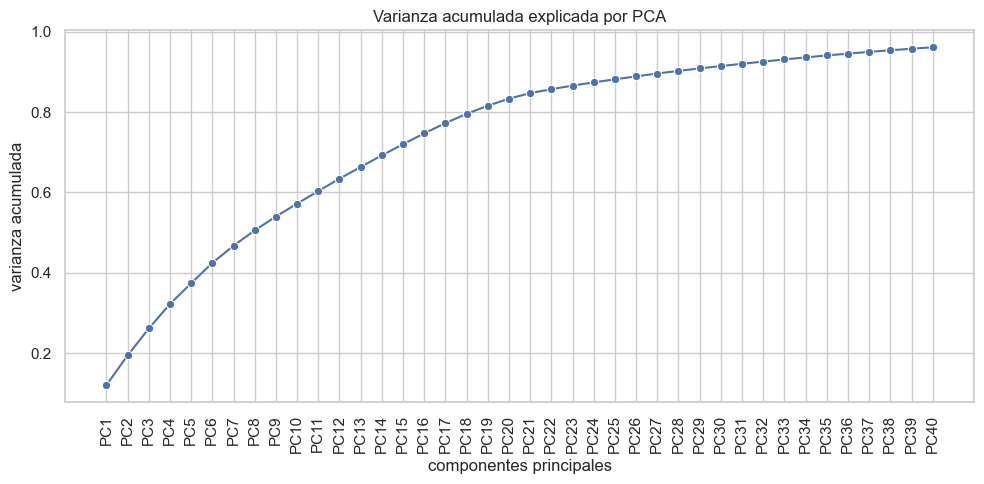

In [13]:
pca = PCA(random_state=RANDOM_SEED)
pca.fit(X_corr_selected)
pca_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

components_80 = int((pca_table["cumulative_variance"] < 0.80).sum() + 1)
components_90 = int((pca_table["cumulative_variance"] < 0.90).sum() + 1)
print("Componentes para explicar al menos 80% de varianza:", components_80)
print("Componentes para explicar al menos 90% de varianza:", components_90)
display(pca_table.head(20))

plt.figure(figsize=(10, 5))
sns.lineplot(data=pca_table.head(40), x="component", y="cumulative_variance", marker="o")
plt.xticks(rotation=90)
plt.title("Varianza acumulada explicada por PCA")
plt.ylabel("varianza acumulada")
plt.xlabel("componentes principales")
plt.tight_layout()
plt.show()

## 10. Dataset final y resumen de ingenieria

El dataset final conserva las variables seleccionadas por filtros supervisados y la variable objetivo. Tambien se genera una tabla de auditoria que documenta origen, transformacion y justificacion de las decisiones.

In [14]:
final_model_ready = X_selected.copy()
final_model_ready[target_col] = y.values
final_model_ready.to_csv(MODEL_READY_PATH, index=False)

summary_rows = []

def add_summary(variable, origin, transformation, justification, kept):
    summary_rows.append({
        "variable": variable,
        "origin": origin,
        "transformation": transformation,
        "justification": justification,
        "kept_in_final_dataset": bool(kept)
    })

for col in base_predictors:
    if col == "synthetic_component_id":
        add_summary(col, "original", "Agrupada como synthetic_component_grouped", "Reducir alta cardinalidad y mejorar generalizacion", False)
    elif col in X_processed.columns or col in X_transformed.columns:
        add_summary(col, "original", "Imputacion y posible escalamiento/log segun tipo", "Preparar senal predictiva sin fuga de informacion", any(col in feature for feature in selected_by_filter))

for col in new_features:
    add_summary(col, "engineered", "Construida a partir de variables existentes", "Capturar complejidad, evidencia, densidad o contexto de riesgo", any(col in feature for feature in selected_by_filter))

for col in X_model.columns:
    if col.startswith("log1p_"):
        add_summary(col, "transformed", "log1p + StandardScaler", "Mitigar sesgo a la derecha y mejorar convergencia", col in selected_by_filter)
    elif col in selected_by_filter and col not in [row["variable"] for row in summary_rows]:
        add_summary(col, "encoded_or_scaled", "One-hot encoding o StandardScaler", "Variable conservada por filtros de seleccion", True)

feature_summary = pd.DataFrame(summary_rows).drop_duplicates(subset=["variable"], keep="last")
feature_summary.to_csv(SUMMARY_PATH, index=False)

print("Archivo model-ready:", MODEL_READY_PATH)
print("Archivo resumen:", SUMMARY_PATH)
print("Shape final:", final_model_ready.shape)
print("Faltantes finales:", int(final_model_ready.isna().sum().sum()))
display(final_model_ready.head())
display(feature_summary.head(30))

Archivo model-ready: data/aurora_features_model_ready.csv
Archivo resumen: data/aurora_feature_engineering_summary.csv
Shape final: (2400, 61)
Faltantes finales: 0


,validation_gap_count,log1p_modules_touched,log1p_files_changed,prior_failures_90d,release_pressure_score,is_high_pressure,critical_files_touched,log1p_tests_impacted_count,log1p_open_defects_linked,log1p_pipeline_duration_min,coverage_delta_pct,log1p_lines_added,is_large_change,log1p_lines_deleted,log1p_change_density_lines_per_file,is_negative_coverage_delta,defects_per_module,net_lines_changed,validation_gap_ratio,reviewer_count,historical_failure_rate,author_experience_months_was_missing,author_experience_months,log1p_tests_per_file_changed,week,branch_type_hotfix,environment_profile_profile_dependency,validation_level_basic_checks,branch_type_development,change_type_feature,branch_type_release_candidate,change_type_bugfix,component_area_functional_area_f,validation_level_integrated_checks,component_area_functional_area_d,environment_profile_profile_standard,environment_profile_profile_extended,validation_level_broad_regression_checks,synthetic_component_grouped_CMP_014,validation_level_readiness_review,synthetic_component_grouped_CMP_010,synthetic_component_grouped_CMP_018,change_type_test,validation_level_component_checks,change_type_configuration,environment_profile_profile_distributed,change_type_refactor,synthetic_component_grouped_CMP_016,change_type_dependency,synthetic_component_grouped_CMP_015,component_area_functional_area_b,component_area_functional_area_c,synthetic_component_grouped_CMP_006,synthetic_component_grouped_other_component,synthetic_component_grouped_CMP_003,component_area_functional_area_a,synthetic_component_grouped_CMP_012,synthetic_component_grouped_CMP_011,component_area_functional_area_e,synthetic_component_grouped_CMP_002,high_risk_change
0,-1.1709,-0.8270,-0.7516,0.0915,0.2323,-0.5818,-0.4519,-2.4611,-0.8322,-0.8988,-0.1772,-0.2316,-0.5774,-1.1769,0.0211,1.0228,-0.6592,-0.0114,-0.2774,-0.2958,0.1856,-0.2171,0.2347,-2.0416,-1.4728,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
1,0.5595,0.1395,-0.3000,2.2036,-1.4958,-0.5818,-0.4519,-0.1418,0.6941,0.0663,0.1928,0.9155,1.7321,-0.3454,0.8712,-0.9777,0.1498,0.5157,-0.0382,3.4020,-0.2208,-0.2171,-1.0460,-0.0062,0.9512,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0
2,-0.3057,0.1395,0.2169,-0.9645,-0.3360,-0.5818,-0.4519,-0.7323,-0.8322,-0.9936,-1.4917,4.4835,1.7321,3.3378,4.7968,1.0228,-0.6592,11.0134,-0.0621,-0.2958,-0.2827,-0.2171,0.7450,-1.0537,0.6049,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
3,1.4246,0.8252,0.4939,0.0915,-3.0325,-0.5818,-0.4519,-1.0158,0.6941,-0.0853,-0.4340,0.2020,-0.5774,-0.7983,-0.7197,1.0228,-0.1199,0.1256,0.5838,-1.0354,-0.1678,-0.2171,-0.2194,-1.4748,-0.2608,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0
4,-1.1709,-0.8270,-0.7516,-0.9645,0.0467,-0.5818,-0.4519,-0.5096,-0.8322,-0.9274,0.4932,-0.5938,-0.5774,0.3793,0.5034,-0.9777,-0.6592,-0.4613,-0.2774,-1.0354,0.8924,-0.2171,-0.5511,-0.1041,-0.2608,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


,variable,origin,transformation,justification,kept_in_final_dataset
0,week,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
1,change_type,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
2,component_area,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
3,synthetic_component_id,original,Agrupada como synthetic_component_grouped,Reducir alta cardinalidad y mejorar generaliza...,False
4,branch_type,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
5,validation_level,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
6,environment_profile,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
7,files_changed,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
8,lines_added,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True
9,lines_deleted,original,Imputacion y posible escalamiento/log segun tipo,Preparar senal predictiva sin fuga de informacion,True


## 11. Validaciones finales

Antes de cerrar la fase se verifican condiciones minimas para que el dataset pueda usarse en modelos posteriores: ausencia de faltantes, ausencia de columnas de fuga, target presente y variables numericas listas para entrenamiento.

In [15]:
forbidden_features = set(leakage_cols + ["change_id"])
leakage_in_final = [col for col in final_model_ready.columns if col in forbidden_features]

validation_results = {
    "rows_final": final_model_ready.shape[0],
    "features_final_without_target": final_model_ready.shape[1] - 1,
    "missing_values_final": int(final_model_ready.isna().sum().sum()),
    "target_rate_high_risk": round(float(final_model_ready[target_col].mean()), 4),
    "leakage_columns_found": leakage_in_final,
    "model_ready_file_exists": MODEL_READY_PATH.exists(),
    "summary_file_exists": SUMMARY_PATH.exists(),
}

for key, value in validation_results.items():
    print(f"{key}: {value}")

assert validation_results["missing_values_final"] == 0
assert not leakage_in_final
assert MODEL_READY_PATH.exists()
assert SUMMARY_PATH.exists()
assert target_col in final_model_ready.columns

rows_final: 2400
features_final_without_target: 60
missing_values_final: 0
target_rate_high_risk: 0.28
leakage_columns_found: []
model_ready_file_exists: True
summary_file_exists: True


## 12. Conclusiones de preparacion de datos en CRISP-ML

La fase de preparacion de datos transforma el dataset explorado en el Avance 1 en una representacion apta para aprendizaje automatico. En el contexto de CRISP-ML, esta etapa conecta el entendimiento del negocio y de los datos con la fase de modelado, asegurando que las variables sean informativas, reproducibles y adecuadas para entrenamiento.

Las principales decisiones fueron:

1. **Evitar fuga de informacion.** Se excluyeron identificadores y variables que representan resultados posteriores al cambio. Esto protege la validez de modelos futuros.

2. **Crear senales de dominio.** Las variables nuevas resumen complejidad, densidad, evidencia y contexto operativo sintetico. Estas senales son mas cercanas al fenomeno que se desea modelar que las columnas crudas por separado.

3. **Mitigar sesgos de escala y distribucion.** Las transformaciones logaritmicas reducen colas largas y el escalamiento permite que algoritmos sensibles a magnitudes comparen variables de forma equilibrada.

4. **Reducir dimensionalidad y complejidad.** La agrupacion de alta cardinalidad, el umbral de varianza, el filtro de correlacion, ANOVA, chi-cuadrado y PCA ayudan a controlar complejidad antes de entrenar modelos.

5. **Mantener trazabilidad.** La tabla de resumen documenta que se transformo, por que se hizo y que variables quedaron disponibles para etapas posteriores.